In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("..\data\game_events.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KEERTHI VARDHAN\AppData\Local\Temp\ipykernel_11724\160401423.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\game_events.csv")


,event_id,player_id,event_name,level_number,timestamp,session_id,revenue,platform,app_version
0,735,30,session_start,NaN,2026-08-01T08:07:00,s_30_0_0,NaN,iOS,2.4.0
1,736,30,level_start,1.0,2026-08-01T08:08:18,s_30_0_0,NaN,iOS,2.4.0
2,737,30,level_fail,1.0,2026-08-01T08:08:48,s_30_0_0,NaN,iOS,2.4.0
3,738,30,session_end,NaN,2026-08-01T08:10:12,s_30_0_0,NaN,iOS,2.4.0
4,2229,90,session_start,NaN,2026-08-01T08:21:00,s_90_0_0,NaN,iOS,2.4.1


In [3]:
df.shape

(4518, 9)

In [4]:
print(df.columns.tolist())

['event_id', 'player_id', 'event_name', 'level_number', 'timestamp', 'session_id', 'revenue', 'platform', 'app_version']


In [5]:
df.dtypes

event_id          int64
player_id         int64
event_name          str
level_number    float64
timestamp           str
session_id          str
revenue         float64
platform            str
app_version         str
dtype: object

In [6]:
df["event_name"].value_counts()

event_name
level_start       1491
level_complete    1118
session_start      758
session_end        758
level_fail         373
purchase            20
Name: count, dtype: int64

In [7]:
print("Unique_palyers:",df["player_id"].nunique())

Unique_palyers: 180


In [8]:
player_events = df.groupby("player_id").size()
player_events.describe()

count    180.00000
mean      25.10000
std       20.25345
min        4.00000
25%        8.00000
50%       20.00000
75%       36.00000
max      106.00000
dtype: float64

In [9]:
df.isnull().sum()

event_id           0
player_id          0
event_name         0
level_number    1536
timestamp          0
session_id         0
revenue         4498
platform           0
app_version        0
dtype: int64

In [10]:
missing_percentage = (
    df.isnull().mean()*100
).sort_values(ascending = False)
missing_percentage

revenue         99.557326
level_number    33.997344
event_id         0.000000
event_name       0.000000
player_id        0.000000
timestamp        0.000000
session_id       0.000000
platform         0.000000
app_version      0.000000
dtype: float64

In [11]:
print("Duplicated Rows:",df.duplicated().sum())

Duplicated Rows: 0


In [12]:
print("Duplicated_event_id:",df["event_id"].duplicated().sum())

Duplicated_event_id: 0


In [13]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [14]:
df["timestamp"].dtype

dtype('<M8[us]')

In [15]:
print("Earliest_event:",df["timestamp"].min())
print("Latest_event:",df["timestamp"].max())

Earliest_event: 2026-08-01 08:07:00
Latest_event: 2026-08-14 23:00:09


In [16]:
#Calendar day analysis
df["event_date"] = df["timestamp"].dt.date

In [17]:
df[["timestamp","event_date"]].head()

,timestamp,event_date
0,2026-08-01 08:07:00,2026-08-01
1,2026-08-01 08:08:18,2026-08-01
2,2026-08-01 08:08:48,2026-08-01
3,2026-08-01 08:10:12,2026-08-01
4,2026-08-01 08:21:00,2026-08-01


Daily Active Users(DAU)

DAU represents the number of unique players who generated atleast one event on each calender day

In [18]:
dau = (
    df.groupby("event_date")["player_id"].nunique()
    .reset_index(name = "dau")
)
dau.head()

,event_date,dau
0,2026-08-01,21
1,2026-08-02,46
2,2026-08-03,51
3,2026-08-04,66
4,2026-08-05,54


In [19]:
dau.tail()

,event_date,dau
9,2026-08-10,44
10,2026-08-11,39
11,2026-08-12,45
12,2026-08-13,38
13,2026-08-14,30


In [20]:
dau.describe()

,dau
count,14.000000
mean,44.142857
std,10.545558
min,21.000000
25%,40.250000
50%,45.500000
75%,47.000000
max,66.000000


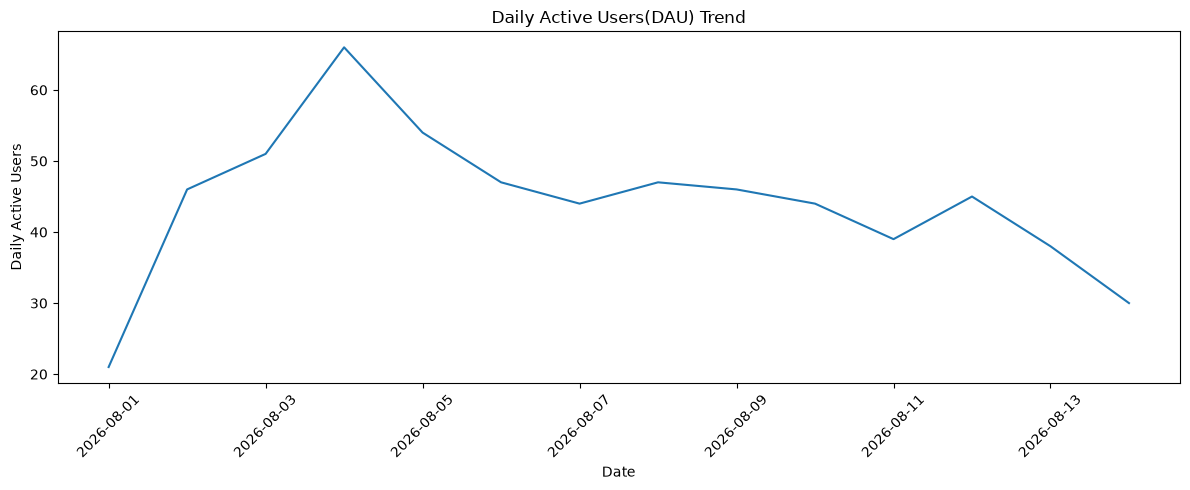

In [21]:
# Dau trend
plt.figure(figsize = (12,5))

plt.plot(dau["event_date"],dau["dau"])

plt.xlabel("Date")
plt.ylabel("Daily Active Users")
plt.title('Daily Active Users(DAU) Trend')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [22]:
print("Avearage DAU:",dau["dau"].mean())
print("Minimum DAU:",dau["dau"].min())
print("Maximum DAU:",dau["dau"].max())

Avearage DAU: 44.142857142857146
Minimum DAU: 21
Maximum DAU: 66


In [23]:
dau.loc[dau["dau"].idxmax()]

event_date    2026-08-04
dau                   66
Name: 3, dtype: object

Level Completion Rate


In [24]:
level_outcomes = df[df["event_name"].isin(["level_complete","level_fail"])
].copy()

level_outcomes.head()

,event_id,player_id,event_name,level_number,timestamp,session_id,revenue,platform,app_version,event_date
2,737,30,level_fail,1.0,2026-08-01 08:08:48,s_30_0_0,NaN,iOS,2.4.0,2026-08-01
6,2231,90,level_complete,1.0,2026-08-01 08:22:59,s_90_0_0,NaN,iOS,2.4.1,2026-08-01
11,1321,54,level_complete,9.0,2026-08-01 08:45:42,s_54_0_0,NaN,iOS,2.5.0,2026-08-01
14,3002,121,level_complete,6.0,2026-08-01 08:47:04,s_121_0_0,NaN,Android,2.4.1,2026-08-01
15,1323,54,level_fail,10.0,2026-08-01 08:47:14,s_54_0_0,NaN,iOS,2.5.0,2026-08-01


In [25]:
level_stats = (
    level_outcomes
    .groupby(["level_number","event_name"])
    .size()
    .unstack(fill_value = 0)
)
level_stats

event_name,level_complete,level_fail
level_number,,
1.0,292,52
2.0,157,36
3.0,101,30
4.0,80,27
5.0,54,24
6.0,71,19
7.0,52,27
8.0,64,16
9.0,39,21


In [26]:
level_stats["completion_rate"] = (
    level_stats["level_complete"] /
    (level_stats["level_complete"] + level_stats["level_fail"])
)

In [27]:
level_stats

event_name,level_complete,level_fail,completion_rate
level_number,,,
1.0,292,52,0.848837
2.0,157,36,0.813472
3.0,101,30,0.770992
4.0,80,27,0.747664
5.0,54,24,0.692308
6.0,71,19,0.788889
7.0,52,27,0.658228
8.0,64,16,0.800000
9.0,39,21,0.650000


In [28]:
level_stats["completion_rate_pct"] = (
    level_stats["completion_rate"] * 100
)

In [29]:
level_stats

event_name,level_complete,level_fail,completion_rate,completion_rate_pct
level_number,,,,
1.0,292,52,0.848837,84.883721
2.0,157,36,0.813472,81.347150
3.0,101,30,0.770992,77.099237
4.0,80,27,0.747664,74.766355
5.0,54,24,0.692308,69.230769
6.0,71,19,0.788889,78.888889
7.0,52,27,0.658228,65.822785
8.0,64,16,0.800000,80.000000
9.0,39,21,0.650000,65.000000


In [30]:
level_stats.sort_values(
    'completion_rate',
    ascending = False
)

event_name,level_complete,level_fail,completion_rate,completion_rate_pct
level_number,,,,
1.0,292,52,0.848837,84.883721
2.0,157,36,0.813472,81.347150
8.0,64,16,0.800000,80.000000
6.0,71,19,0.788889,78.888889
3.0,101,30,0.770992,77.099237
4.0,80,27,0.747664,74.766355
10.0,42,16,0.724138,72.413793
13.0,32,14,0.695652,69.565217
5.0,54,24,0.692308,69.230769


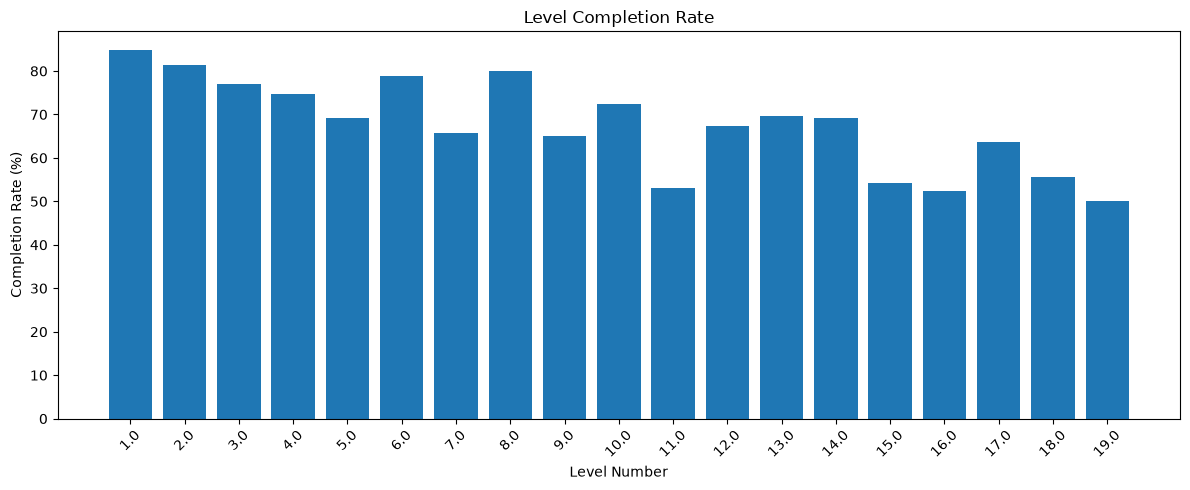

In [31]:
plt.figure(figsize = (12,5))

plt.bar(
    level_stats.index.astype(str),
    level_stats["completion_rate_pct"]
)

plt.xlabel("Level Number")
plt.ylabel("Completion Rate (%)")
plt.title("Level Completion Rate")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [32]:
# Session Duration

session_events = df[
    df["event_name"].isin(["session_start","session_end"])
].copy()
session_events.head()

,event_id,player_id,event_name,level_number,timestamp,session_id,revenue,platform,app_version,event_date
0,735,30,session_start,NaN,2026-08-01 08:07:00,s_30_0_0,NaN,iOS,2.4.0,2026-08-01
3,738,30,session_end,NaN,2026-08-01 08:10:12,s_30_0_0,NaN,iOS,2.4.0,2026-08-01
4,2229,90,session_start,NaN,2026-08-01 08:21:00,s_90_0_0,NaN,iOS,2.4.1,2026-08-01
7,2232,90,session_end,NaN,2026-08-01 08:24:54,s_90_0_0,NaN,iOS,2.4.1,2026-08-01
8,1319,54,session_start,NaN,2026-08-01 08:43:00,s_54_0_0,NaN,iOS,2.5.0,2026-08-01


In [33]:
session_check = (
    session_events
    .groupby(["session_id","event_name"])
    .size()
    .unstack(fill_value = 0)
)

In [34]:
session_check

event_name,session_end,session_start
session_id,,
s_100_10_0,1,1
s_101_1_0,1,1
s_102_3_0,1,1
s_102_5_0,1,1
s_102_6_0,1,1
...,...,...
s_99_5_0,1,1
s_99_6_0,1,1
s_9_1_0,1,1


In [35]:
print("Total Unique Sessions:",df["session_id"].nunique())

print(
    "Sessions with both start and end",
    ((session_check["session_start"] > 0) & 
     (session_check["session_end"] > 0)).sum()
)

Total Unique Sessions: 758
Sessions with both start and end 758


In [36]:
sessions = (
    session_events
    .pivot_table(
        index = "session_id",
        columns = "event_name",
        values = "timestamp",
        aggfunc = "min"
    )
    .reset_index()
)
sessions.head()

event_name,session_id,session_end,session_start
0,s_100_10_0,2026-08-11 19:16:05,2026-08-11 19:06:00
1,s_101_1_0,2026-08-02 13:35:31,2026-08-02 13:31:00
2,s_102_3_0,2026-08-04 18:35:39,2026-08-04 18:31:00
3,s_102_5_0,2026-08-06 10:32:44,2026-08-06 10:25:00
4,s_102_6_0,2026-08-07 12:52:57,2026-08-07 12:48:00


In [37]:
sessions["duration_sec"] = (
    sessions["session_end"] - 
    sessions["session_start"]
).dt.total_seconds()

In [38]:
sessions.head()

event_name,session_id,session_end,session_start,duration_sec
0,s_100_10_0,2026-08-11 19:16:05,2026-08-11 19:06:00,605.0
1,s_101_1_0,2026-08-02 13:35:31,2026-08-02 13:31:00,271.0
2,s_102_3_0,2026-08-04 18:35:39,2026-08-04 18:31:00,279.0
3,s_102_5_0,2026-08-06 10:32:44,2026-08-06 10:25:00,464.0
4,s_102_6_0,2026-08-07 12:52:57,2026-08-07 12:48:00,297.0


In [39]:
sessions["duration_sec"].describe()

count     758.000000
mean      453.189974
std       221.672353
min       103.000000
25%       280.000000
50%       393.000000
75%       595.750000
max      1152.000000
Name: duration_sec, dtype: float64

In [40]:
print("Negative Durations:",
      (sessions["duration_sec"] < 0).sum())

print("Zero Duration:",
      (sessions["duration_sec"] == 0).sum())

print("Missing Duration",
      (sessions["duration_sec"].isna()).sum())

Negative Durations: 0
Zero Duration: 0
Missing Duration 0


In [41]:
purchase_events = df[df["event_name"] == "purchase"].copy()
purchase_events.head()

,event_id,player_id,event_name,level_number,timestamp,session_id,revenue,platform,app_version,event_date
297,378,17,purchase,NaN,2026-08-02 11:19:26,s_17_1_0,4.99,Android,2.4.0,2026-08-02
786,1470,59,purchase,NaN,2026-08-03 17:19:53,s_59_2_1,0.99,iOS,2.4.0,2026-08-03
1117,618,25,purchase,NaN,2026-08-04 13:34:54,s_25_3_0,9.99,iOS,2.4.0,2026-08-04
1757,1301,52,purchase,NaN,2026-08-05 20:48:53,s_52_4_1,19.99,Android,2.5.0,2026-08-05
1763,3071,123,purchase,NaN,2026-08-05 20:53:40,s_123_4_0,9.99,Android,2.5.0,2026-08-05


In [42]:
print("Purchase Events:",len(purchase_events))

print("Missing revenue:",
      purchase_events["revenue"].isna().sum())

print("Zero revenue ",
      (purchase_events["revenue"] == 0).sum())

print("Negative Revenue:",
(purchase_events["revenue"] < 0).sum())

Purchase Events: 20
Missing revenue: 0
Zero revenue  0
Negative Revenue: 0


In [43]:
total_revenue = purchase_events["revenue"].sum()
paying_players = purchase_events["player_id"].nunique()
arppu = total_revenue / paying_players

print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Paying Players: {paying_players}")
print(f"ARPPU: ${arppu:.2f}")

Total Revenue: $169.80
Paying Players: 11
ARPPU: $15.44


Retention 

In [44]:
player_first_day =  (
    df.groupby('player_id')["event_date"]
    .min()
    .reset_index(name = "first_event_date")
)
player_first_day.head()

,player_id,first_event_date
0,1,2026-08-07
1,2,2026-08-09
2,3,2026-08-02
3,4,2026-08-04
4,5,2026-08-04


In [45]:
player_days = (
    df[["player_id","event_date"]]
    .drop_duplicates()
)

In [46]:
retention = player_days.merge(
    player_first_day,
    on = "player_id",
    how = "left"
)

In [47]:
retention["is_day1_return"] = (
    retention["event_date"] == 
    retention["first_event_date"] + pd.Timedelta(days = 1)
)

In [48]:
day1_retention = (
    retention
    .groupby("first_event_date")
    .agg(
        cohort_players = ("player_id","nunique"),
        retained_players = ("is_day1_return","sum")
    )
    .reset_index()
)

In [49]:
day1_retention["day1_retention_rate"] = (
    day1_retention["retained_players"] / day1_retention["cohort_players"]
)

In [50]:
day1_retention["day1_retention_pct"] = (
    day1_retention["day1_retention_rate"] * 100
)

In [51]:
day1_retention

,first_event_date,cohort_players,retained_players,day1_retention_rate,day1_retention_pct
0,2026-08-01,21,10,0.476190,47.619048
1,2026-08-02,36,17,0.472222,47.222222
2,2026-08-03,27,14,0.518519,51.851852
3,2026-08-04,24,13,0.541667,54.166667
4,2026-08-05,6,3,0.500000,50.000000
5,2026-08-06,5,2,0.400000,40.000000
6,2026-08-07,8,5,0.625000,62.500000
7,2026-08-08,7,4,0.571429,57.142857
8,2026-08-09,10,6,0.600000,60.000000
9,2026-08-10,7,3,0.428571,42.857143


In [52]:
dataset_latest_date = df["event_date"].max()

day1_retention = day1_retention[
    day1_retention["first_event_date"] < dataset_latest_date
].copy()

In [53]:
day1_retention

,first_event_date,cohort_players,retained_players,day1_retention_rate,day1_retention_pct
0,2026-08-01,21,10,0.476190,47.619048
1,2026-08-02,36,17,0.472222,47.222222
2,2026-08-03,27,14,0.518519,51.851852
3,2026-08-04,24,13,0.541667,54.166667
4,2026-08-05,6,3,0.500000,50.000000
5,2026-08-06,5,2,0.400000,40.000000
6,2026-08-07,8,5,0.625000,62.500000
7,2026-08-08,7,4,0.571429,57.142857
8,2026-08-09,10,6,0.600000,60.000000
9,2026-08-10,7,3,0.428571,42.857143


In [54]:
overall_day1_retention = (
    day1_retention["retained_players"].sum()
     / day1_retention["cohort_players"].sum()
)

print(f"Overall_day1_retention:{overall_day1_retention: .2%}")

Overall_day1_retention: 48.26%


Session Duration by each platform

In [55]:
session_platform = (
    df[df["event_name"] == "session_start"]
    [["session_id","player_id","platform"]]
    .drop_duplicates("session_id")
)

In [56]:
sessions = sessions.merge(
    session_platform,
    on = "session_id",
    how = "left"
)

In [57]:
sessions[[
    "session_id",
    "player_id",
    "platform",
    "duration_sec"
]].head()

,session_id,player_id,platform,duration_sec
0,s_100_10_0,100,iOS,605.0
1,s_101_1_0,101,iOS,271.0
2,s_102_3_0,102,Android,279.0
3,s_102_5_0,102,Android,464.0
4,s_102_6_0,102,Android,297.0


In [58]:
sessions["platform"].value_counts()

platform
iOS        405
Android    353
Name: count, dtype: int64

In [59]:
platform_summary = (
    sessions
    .groupby("platform")["duration_sec"]
    .agg(["count","mean","std","median"])
)
platform_summary

,count,mean,std,median
platform,,,,
Android,353,465.872521,218.706043,424.0
iOS,405,442.135802,223.909323,365.0


In [60]:
andriod_duration = sessions.loc[
    sessions["platform"] == "Android",
    "duration_sec"
]

ios_duration= sessions.loc[
    sessions["platform"] == "iOS",
    "duration_sec"
]

In [61]:
print("Android Sessions:",len(andriod_duration))
print("iOS Sessions:",len(ios_duration))

Android Sessions: 353
iOS Sessions: 405


### Hypothesis Test

**Null hypothesis (H₀):**  
The mean session duration is the same for Android and iOS players.

**Alternative hypothesis (H₁):**  
The mean session duration differs between Android and iOS players.

A two-sided Welch's independent-samples t-test is used with α = 0.05.

In [62]:
from scipy import stats

In [63]:
t_stat,p_value = stats.ttest_ind(
    andriod_duration,
    ios_duration,
    equal_var = False
)

print(f"t-statistic:{t_stat: .4f}")
print(f"p-value:{p_value: .4f}")

t-statistic: 1.4741
p-value: 0.1409


### Statistical Test Result

The average session duration was 465.87 seconds for Android and
442.14 seconds for iOS, an observed difference of approximately
23.74 seconds.

A two-sided Welch's independent-samples t-test was performed because
the two platform groups are independent and equal population variances
were not assumed.

- t-statistic = 1.4741
- p-value = 0.1409
- Significance level (α) = 0.05

Since p > 0.05, we fail to reject the null hypothesis. Therefore,
there is insufficient statistical evidence in this dataset to conclude
that average session duration differs between Android and iOS players.

In [64]:
from scipy.stats import t

n_android = len(andriod_duration)
n_ios = len(ios_duration)

mean_android = andriod_duration.mean()
mean_ios = ios_duration.mean()

var_android = andriod_duration.var(ddof=1)
var_ios = ios_duration.var(ddof=1)

mean_diff = mean_android - mean_ios

se_diff = np.sqrt(
    var_android / n_android +
    var_ios / n_ios
)

df_welch = (
    (var_android / n_android + var_ios / n_ios) ** 2
    /
    (
        (var_android / n_android) ** 2 / (n_android - 1)
        +
        (var_ios / n_ios) ** 2 / (n_ios - 1)
    )
)

critical_value = t.ppf(0.975, df_welch)

ci_lower = mean_diff - critical_value * se_diff
ci_upper = mean_diff + critical_value * se_diff

print(f"Mean difference (Android - iOS): {mean_diff:.2f} sec")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

Mean difference (Android - iOS): 23.74 sec
95% CI: (-7.88, 55.35)


### 95% Confidence Interval

The estimated difference in mean session duration between Android and
iOS was 23.74 seconds (Android - iOS).

The 95% confidence interval for this difference was [-7.88, 55.35]
seconds. Since the interval includes zero, a zero difference is
compatible with the observed data.

This supports the Welch's t-test result (p = 0.1409): there is
insufficient statistical evidence at the 5% significance level to
conclude that mean session duration differs between Android and iOS.

In [65]:
player_sessions_features = (
    sessions
    .groupby("player_id")
    .agg(
        sessions_count = ("session_id","nunique"),
        avg_session_duration_sec = ("duration_sec","mean")
    )
    .reset_index()
)
player_sessions_features.head()

,player_id,sessions_count,avg_session_duration_sec
0,1,3,214.000000
1,2,2,646.500000
2,3,7,540.857143
3,4,4,773.000000
4,5,4,516.750000


In [66]:
player_level_features = (
    df[df["event_name"].isin(["level_complete","level_fail"])]
    .groupby(["player_id","event_name"])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)

In [67]:
player_level_features = player_level_features.rename(
    columns = {
        "level_complete" :"levels_completed",
        "level_fail" :"levels_failed"
    }
)
player_level_features.head()

event_name,player_id,levels_completed,levels_failed
0,1,2,1
1,2,5,0
2,3,14,5
3,4,7,7
4,5,8,0


In [68]:
player_spend = (
    df[df["event_name"] == "purchase"]
    .groupby("player_id")["revenue"]
    .sum()
    .reset_index(name = "total_spend")
)
player_spend.head()

,player_id,total_spend
0,17,36.96
1,25,30.96
2,32,4.99
3,52,19.99
4,59,0.99


In [69]:
player_features_eda = (
    df[["player_id"]].drop_duplicates()
)

In [70]:
player_features_eda = (
    player_features_eda
    .merge(player_sessions_features,on = "player_id",how = "left")
    .merge(player_level_features,on = "player_id",how = "left")
    .merge(player_spend,on = "player_id",how = "left")
)

In [71]:
player_features_eda[
    [
        "sessions_count",
        "avg_session_duration_sec",
        "levels_completed",
        "levels_failed",
        "total_spend"
    ]
] = player_features_eda[
    [
        "sessions_count",
        "avg_session_duration_sec",
        "levels_completed",
        "levels_failed",
        "total_spend"
    ]
].fillna(0)

In [72]:
player_features_eda.head()

,player_id,sessions_count,avg_session_duration_sec,levels_completed,levels_failed,total_spend
0,30,6,425.500000,8,2,0.0
1,90,7,389.857143,7,2,0.0
2,54,8,472.375000,11,7,0.0
3,121,2,223.500000,1,1,0.0
4,104,10,261.900000,10,1,0.0


In [73]:
player_features_eda.shape

(180, 6)

## 7.2 Engagement Features vs Total Spend

We examine the association between player engagement metrics and total
spend using Pearson correlation coefficients.

Correlation measures the strength and direction of a linear association.
It does not establish a causal relationship.

In [74]:
engagement_features = [
    "sessions_count",
    "avg_session_duration_sec",
    "levels_completed",
    "levels_failed",
]


correlations = (
    player_features_eda[
        engagement_features + ["total_spend"]
    ]
    .corr()["total_spend"]
    .drop("total_spend")
    .sort_values(ascending = False)
)
correlations

sessions_count              0.263554
levels_failed               0.187783
levels_completed            0.182279
avg_session_duration_sec   -0.013449
Name: total_spend, dtype: float64

In [75]:
correlation_summary = pd.DataFrame({
    "correlation_with_total_spend": correlations,
    "absolute_correlation": correlations.abs()
}).sort_values(
    "absolute_correlation",
    ascending=False
)

correlation_summary

,correlation_with_total_spend,absolute_correlation
sessions_count,0.263554,0.263554
levels_failed,0.187783,0.187783
levels_completed,0.182279,0.182279
avg_session_duration_sec,-0.013449,0.013449


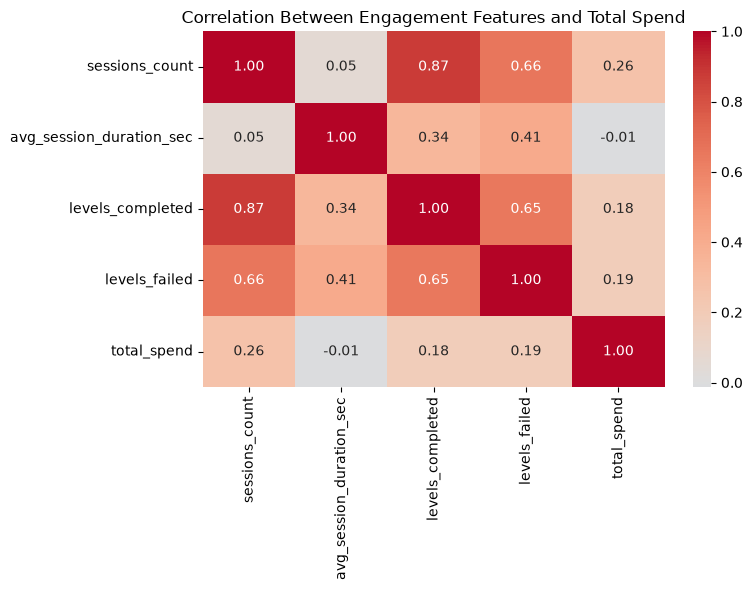

In [76]:
import seaborn as sns

plt.figure(figsize = (8,6))

corr_matrix = player_features_eda[
    engagement_features + ["total_spend"]
].corr()

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    center = 0
)

plt.title("Correlation Between Engagement Features and Total Spend")
plt.tight_layout()
plt.show()



In [77]:
print("Total players:", len(player_features_eda))

print(
    "Paying players:",
    (player_features_eda["total_spend"] > 0).sum()
)

print(
    "Non-paying players:",
    (player_features_eda["total_spend"] == 0).sum()
)

Total players: 180
Paying players: 11
Non-paying players: 169


In [78]:
#Revenue Concentration by players
player_spend = (
    purchase_events.groupby("player_id")["revenue"]
    .sum()
    .sort_values(ascending = False)
)

top3_revenue = player_spend.head(3).sum()
total_revenue = player_spend.sum()

top3_percentage = (top3_revenue / total_revenue) * 100

print("Total Revenue:",total_revenue)
print("Top 3 Players Revenue:",top3_revenue)
print("Top 3 revenue contribution:",top3_percentage,"%")

Total Revenue: 169.8
Top 3 Players Revenue: 97.9
Top 3 revenue contribution: 57.65606595995288 %


## Product Insights

1. DAU varied considerably across the observation period, indicating changes in daily player activity.

2. Level completion rates generally decreased across several levels, although completion rate alone cannot establish whether a level is poorly designed. Lower-completion levels can be investigated further using difficulty, failure patterns, and player progression.

3. Average session duration was approximately 7.5 minutes, with a median of approximately 6.6 minutes, indicating some variation in session length.

4. Android sessions had a higher mean duration than iOS sessions, but Welch's t-test did not provide sufficient statistical evidence of a difference in mean session duration between the two platforms.

5. Among the engagement variables examined, session count had the strongest Pearson correlation with total spending (r ≈ 0.264). This represents a weak positive association and should not be interpreted as a causal relationship.

6. Revenue was concentrated among a small number of paying players. The top three spenders contributed approximately 57.7% of total revenue, indicating that player-level spending distribution is important when interpreting monetization metrics.

7. D1 retention provides an early measure of whether newly acquired players return on the following day. The final cohort was excluded because its D+1 observation was not available within the dataset.

Part 2

In [79]:
session_features = (
    sessions.groupby("player_id")["duration_sec"]
    .agg(
        sessions_count_total = "count",
        avg_session_duration_sec = "mean",
    )
    .reset_index()
)

session_features.head()

,player_id,sessions_count_total,avg_session_duration_sec
0,1,3,214.000000
1,2,2,646.500000
2,3,7,540.857143
3,4,4,773.000000
4,5,4,516.750000


In [80]:
level_features = (
    df.assign(
        completed = (df["event_name"] == "level_complete").astype(int),
        failed = (df["event_name"] == "level_fail").astype(int)    
)
    .groupby("player_id")
    .agg(
        levels_completed = ("completed","sum"),
        levels_failed = ("failed","sum")
    )
    .reset_index()
)

level_features.head()

,player_id,levels_completed,levels_failed
0,1,2,1
1,2,5,0
2,3,14,5
3,4,7,7
4,5,8,0


In [81]:
purchase_features = (
    df.assign(
        purchase_flag = (df["event_name"] == "purchase").astype(int),
        purchase_revenue = df["revenue"].fillna(0)
    )
    .groupby("player_id")
    .agg(
        purchases_count = ("purchase_flag","sum"),
        total_spend = ("purchase_revenue","sum")
    )
    .reset_index()
)
purchase_features.head()

,player_id,purchases_count,total_spend
0,1,0,0.0
1,2,0,0.0
2,3,0,0.0
3,4,0,0.0
4,5,0,0.0


In [82]:
player_activity = (
    df.groupby("player_id")["timestamp"]
    .agg(
        first_event_time="min",
        last_event_time="max"
    )
    .reset_index()
)

player_activity.head()


,player_id,first_event_time,last_event_time
0,1,2026-08-07 17:20:00,2026-08-14 17:04:29
1,2,2026-08-09 09:08:00,2026-08-10 14:35:08
2,3,2026-08-02 09:48:00,2026-08-11 12:25:50
3,4,2026-08-04 14:37:00,2026-08-12 11:05:23
4,5,2026-08-04 15:58:00,2026-08-07 20:49:15


In [83]:
dataset_latest_timestamp = df["timestamp"].max()

player_activity["days_since_install"] = (
    dataset_latest_timestamp - player_activity["first_event_time"]
).dt.total_seconds() / (24 * 60 * 60)

player_activity["days_since_last_active"] = (
    dataset_latest_timestamp - player_activity["last_event_time"]
).dt.total_seconds() / (24 * 60 * 60)

player_activity.head()

,player_id,first_event_time,last_event_time,days_since_install,days_since_last_active
0,1,2026-08-07 17:20:00,2026-08-14 17:04:29,7.236215,0.246991
1,2,2026-08-09 09:08:00,2026-08-10 14:35:08,5.577882,4.350706
2,3,2026-08-02 09:48:00,2026-08-11 12:25:50,12.550104,3.440498
3,4,2026-08-04 14:37:00,2026-08-12 11:05:23,10.349410,2.496366
4,5,2026-08-04 15:58:00,2026-08-07 20:49:15,10.293160,7.090903


In [84]:
player_features = (
    df[["player_id"]].drop_duplicates()
    .merge(session_features,on = "player_id",how = "left")
    .merge(level_features,on = "player_id",how = "left")
    .merge(purchase_features,on = "player_id",how = "left")
    .merge(player_activity,on = "player_id",how = "left")
)
player_features.head()

,player_id,sessions_count_total,avg_session_duration_sec,levels_completed,levels_failed,purchases_count,total_spend,first_event_time,last_event_time,days_since_install,days_since_last_active
0,30,6,425.500000,8,2,0,0.0,2026-08-01 08:07:00,2026-08-12 14:05:35,13.620243,2.371227
1,90,7,389.857143,7,2,0,0.0,2026-08-01 08:21:00,2026-08-14 13:12:24,13.610521,0.408160
2,54,8,472.375000,11,7,0,0.0,2026-08-01 08:43:00,2026-08-11 18:18:28,13.595243,3.195613
3,121,2,223.500000,1,1,0,0.0,2026-08-01 08:45:00,2026-08-04 12:28:01,13.593854,10.438981
4,104,10,261.900000,10,1,0,0.0,2026-08-01 10:19:00,2026-08-10 10:42:15,13.528576,4.512431


In [85]:
zero_features = [
    "sessions_count_total",
    "avg_session_duration_sec",
    "levels_completed",
    "levels_failed",
    "purchases_count",
    "total_spend"
]

player_features[zero_features] = (
    player_features[zero_features].fillna(0)
)

player_features.head()

,player_id,sessions_count_total,avg_session_duration_sec,levels_completed,levels_failed,purchases_count,total_spend,first_event_time,last_event_time,days_since_install,days_since_last_active
0,30,6,425.500000,8,2,0,0.0,2026-08-01 08:07:00,2026-08-12 14:05:35,13.620243,2.371227
1,90,7,389.857143,7,2,0,0.0,2026-08-01 08:21:00,2026-08-14 13:12:24,13.610521,0.408160
2,54,8,472.375000,11,7,0,0.0,2026-08-01 08:43:00,2026-08-11 18:18:28,13.595243,3.195613
3,121,2,223.500000,1,1,0,0.0,2026-08-01 08:45:00,2026-08-04 12:28:01,13.593854,10.438981
4,104,10,261.900000,10,1,0,0.0,2026-08-01 10:19:00,2026-08-10 10:42:15,13.528576,4.512431


In [86]:
print("Shape:", player_features.shape)
print("\nMissing values:")
print(player_features.isna().sum())

Shape: (180, 11)

Missing values:
player_id                   0
sessions_count_total        0
avg_session_duration_sec    0
levels_completed            0
levels_failed               0
purchases_count             0
total_spend                 0
first_event_time            0
last_event_time             0
days_since_install          0
days_since_last_active      0
dtype: int64


In [87]:
player_features["days_since_last_active"].describe()

count    180.000000
mean       4.689046
std        3.934988
min        0.000000
25%        1.253466
50%        3.590417
75%        7.396672
max       13.361192
Name: days_since_last_active, dtype: float64

In [88]:
print(
    player_features["days_since_last_active"]
    .sort_values(ascending=False)
    .head(20)
)

10    13.361192
7     13.294942
13    13.269016
14    13.065556
37    12.392106
40    12.358993
46    12.247894
48    12.222697
47    12.221134
49    12.164387
51    12.132454
52    12.113495
34    11.431100
65    11.383727
71    11.302269
75    11.174641
78    11.109028
79    11.090475
61    11.070764
70    10.999433
Name: days_since_last_active, dtype: float64


In [89]:
player_features["at_risk"] = (
    player_features["days_since_last_active"] > 3
).astype(int)

In [90]:
print(player_features["at_risk"].value_counts())
print()
print(player_features["at_risk"].value_counts(normalize=True) * 100)

at_risk
1    99
0    81
Name: count, dtype: int64

at_risk
1    55.0
0    45.0
Name: proportion, dtype: float64


In [91]:
player_features[
    ["player_id","days_since_last_active","at_risk"]
].sort_values("days_since_last_active",ascending=False).head(15)

,player_id,days_since_last_active,at_risk
10,96,13.361192,1
7,132,13.294942,1
13,68,13.269016,1
14,61,13.065556,1
37,101,12.392106,1
40,136,12.358993,1
46,29,12.247894,1
48,56,12.222697,1
47,40,12.221134,1
49,83,12.164387,1


In [92]:
feature_columns = [
    "sessions_count_total",
    "avg_session_duration_sec",
    "levels_completed",
    "levels_failed",
    "purchases_count",
    "total_spend",
    "days_since_install"
]

X  = player_features[feature_columns]
y = player_features["at_risk"]

print("X shape:",X.shape)
print("y shape:",y.shape)
print("\n Target distribution:")
print(y.value_counts())

X shape: (180, 7)
y shape: (180,)

 Target distribution:
at_risk
1    99
0    81
Name: count, dtype: int64


In [93]:
print(X.isna().sum())

sessions_count_total        0
avg_session_duration_sec    0
levels_completed            0
levels_failed               0
purchases_count             0
total_spend                 0
days_since_install          0
dtype: int64


In [94]:
print(y.value_counts(normalize=True) * 100)

at_risk
1    55.0
0    45.0
Name: proportion, dtype: float64


In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

In [96]:
model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    class_weight = "balanced"
)

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = cross_validate(
    model,
    X,
    y,
    cv = cv,
    scoring = scoring,
)

In [97]:
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(
        f"{metric}",
        f"{scores.mean():.4f}"
        f" ± {scores.std():.4f}"
    )

accuracy 0.7722 ± 0.0539
precision 0.7900 ± 0.0166
recall 0.7989 ± 0.1257
f1 0.7889 ± 0.0713
roc_auc 0.8615 ± 0.0400


In [98]:
model.fit(X,y)

feature_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance",ascending=False)

feature_importances

,feature,importance
6,days_since_install,0.446548
1,avg_session_duration_sec,0.178511
0,sessions_count_total,0.131871
2,levels_completed,0.130782
3,levels_failed,0.078567
5,total_spend,0.018487
4,purchases_count,0.015234


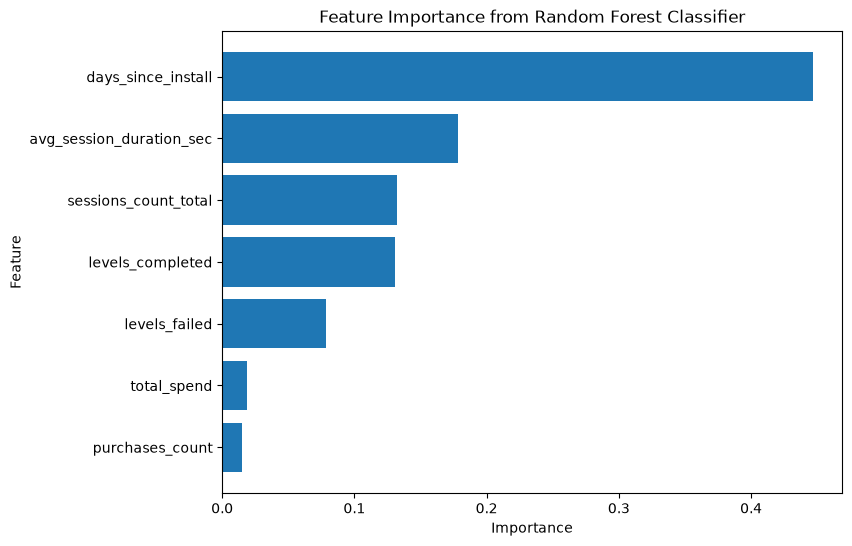

In [99]:
plt.figure(figsize = (8,6))

plt.barh(
    feature_importances["feature"],
    feature_importances["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from Random Forest Classifier")
plt.gca().invert_yaxis()
plt.show()

In [100]:
# Leakage check

print("Model features:")
print(X.columns.tolist())

print("\nIs days_since_last_active included?")
print("days_since_last_active" in X.columns)

Model features:
['sessions_count_total', 'avg_session_duration_sec', 'levels_completed', 'levels_failed', 'purchases_count', 'total_spend', 'days_since_install']

Is days_since_last_active included?
False


In [101]:
print("\nTarget definition:")
print("at_risk = days_since_last_active > 3")


Target definition:
at_risk = days_since_last_active > 3


## Leakage Check

The target `at_risk` was defined as players with more than 3 days since their last activity.

Because `days_since_last_active` directly determines the target, including it as a model feature would cause target leakage. The model could simply reproduce the labeling rule instead of learning meaningful player behavior.

Therefore, `days_since_last_active` is retained in the player-level feature table for analysis but excluded from the predictor matrix `X`.

`days_since_install` is included, but its high importance is interpreted cautiously because the dataset is a short 14-day observation window and older players have had more time to become inactive.

In [102]:

depths = [3,5,10,15,None]

tuning_results = []

for depth in depths:
    
    tuned_model = RandomForestClassifier(
        n_estimators = 200,
        max_depth = depth,
        random_state = 42,
        class_weight = "balanced"
    )
    
    scores = cross_validate(
        tuned_model,
        X,
        y,
        cv = cv,
        scoring = scoring,
    )
    tuning_results.append({
        "max_depth": depth,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })
    
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df
    


,max_depth,accuracy,precision,recall,f1,roc_auc
0,3.0,0.766667,0.795861,0.787895,0.787019,0.863942
1,5.0,0.794444,0.816395,0.818421,0.810391,0.872038
2,10.0,0.772222,0.780115,0.818947,0.792197,0.868635
3,15.0,0.772222,0.790043,0.798947,0.788878,0.862122
4,NaN,0.772222,0.790043,0.798947,0.788878,0.861500


## Hyperparameter Tuning

A light hyperparameter search was performed on the Random Forest `max_depth` parameter using the same stratified 5-fold cross-validation procedure.

The tested values were 3, 5, 10, 15, and unlimited depth.

A maximum depth of 5 produced the strongest overall cross-validated performance, with mean accuracy of 79.44%, precision of 81.64%, recall of 81.84%, F1-score of 81.04%, and ROC-AUC of 87.20%.

Compared with the initial model, which achieved an F1-score of 78.89% and ROC-AUC of 86.15%, the tuned model improved both metrics.

Therefore, `max_depth=5` was selected for the final model.

In [103]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [104]:
import os
os.makedirs("models", exist_ok=True)

In [105]:
import pickle

In [106]:
model_path = "models/at_risk_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(final_model, file)
    
print(f"Model saved to {model_path}")

Model saved to models/at_risk_model.pkl


In [107]:
feature_metadata = {
    "features": feature_columns,
    "at_risk_rule": "days_since_last_active > 3",
    "max_depth": 5
}

with open("models/model_metadata.pkl", "wb") as file:
    pickle.dump(feature_metadata, file)

print("Model metadata saved.")

Model metadata saved.


In [108]:
with open("models/at_risk_model.pkl", "rb") as file:
    model = pickle.load(file)

In [110]:
import os
os.makedirs("database", exist_ok=True)
player_features.to_csv("database/player_features.csv", index=False)

In [111]:
player_features.shape

(180, 12)